# Relation-Agnostic Error Analysis.
This notebook examines whether certain sentence aspects (not specific to relations) influence the model performance. The following aspects of a sentence are taken into consideration:
- sentence length: are longer sentences more challenging to analyse for the model since they contain a lot of information and some may not be relevant to the relation?
- entity distance: are sentences with more distant subject and object entity more challenging for the model? For example it may happen that the LSTM model in some sense "forgets" about the first entity by the time it reaches the second.

In [1]:
import torch
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import json
import matplotlib.pyplot as plt

from collections import Counter
from utils import scorer

/Users/samuele/opt/anaconda3/envs/tuwnlpie/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Disable print
def blockPrint():
    sys.stdout = open(os.devnull, "w")


# Restore
def enablePrint():
    sys.stdout = sys.__stdout__

## Error analysis

First let us investigate the model selected using the TACREV data for validation and test.

Note that, the TACREV test set does NOT contain relation `per:country_of_birth`

In [3]:
# Read data from the text file into a DataFrame
file_path = "evaluation/errors_TACREV_model.txt"

In [4]:
error_df = pd.read_csv(file_path, sep="\t")
error_df.reset_index(inplace=True)

In [5]:
summary_data = scorer.score(
    error_df["Gold Label"], error_df["Prediction"], verbose=True, return_data=True
)

Per-relation statistics:
org:alternate_names                  P:  95.98%  R:  87.76%  F1:  91.68%  #: 245
org:city_of_headquarters             P:  82.98%  R:  87.64%  F1:  85.25%  #: 89
org:country_of_headquarters          P:  91.43%  R:  34.78%  F1:  50.39%  #: 92
org:dissolved                        P: 100.00%  R:   0.00%  F1:   0.00%  #: 1
org:founded                          P:  86.84%  R:  89.19%  F1:  88.00%  #: 37
org:founded_by                       P:  80.56%  R:  38.16%  F1:  51.79%  #: 76
org:member_of                        P: 100.00%  R:   0.00%  F1:   0.00%  #: 4
org:members                          P:   0.00%  R:   0.00%  F1:   0.00%  #: 16
org:number_of_employees/members      P: 100.00%  R:  42.86%  F1:  60.00%  #: 14
org:parents                          P:  32.00%  R:  14.04%  F1:  19.51%  #: 57
org:political/religious_affiliation  P:  28.00%  R:  70.00%  F1:  40.00%  #: 10
org:shareholders                     P:   0.00%  R:   0.00%  F1:   0.00%  #: 3
org:stateorprovin

In [6]:
# We have count of occurrences if each relation in the test set. We add to the table also the count of occurences in the training set
with open("../../../data/tacred/json/train.json", "r") as file:
    data_train = json.load(file)
training_data = pd.json_normalize(data_train)

# Count occurrences of each relation in the training set
relation_counts = training_data["relation"].value_counts()
relation_counts = relation_counts.sort_index()
relation_counts = relation_counts[
    (relation_counts.index != "per:country_of_birth")
    & (relation_counts.index != "no_relation")
]

In [7]:
summary_data["train_counts"] = list(relation_counts)
summary_data["train_%"] = (
    summary_data["train_counts"] / sum(summary_data["train_counts"]) * 100
)
summary_data["test_%"] = (
    summary_data["test_counts"] / sum(summary_data["test_counts"]) * 100
)

In [8]:
summary_data.sort_values(by="F1", ascending=True).head(
    10
)  # We can see the 10 relations with lowest F1 score

,Relation,Precision,Recall,F1,test_counts,train_counts,train_%,test_%
3,org:dissolved,1.000000,0.000000,0.000000,1,22,0.181309,0.032020
7,org:members,0.000000,0.000000,0.000000,16,155,1.277402,0.512328
6,org:member_of,1.000000,0.000000,0.000000,4,113,0.931268,0.128082
11,org:shareholders,0.000000,0.000000,0.000000,3,70,0.576891,0.096061
25,per:country_of_death,1.000000,0.000000,0.000000,10,6,0.049448,0.320205
9,org:parents,0.320000,0.140351,0.195122,57,268,2.208670,1.825168
37,per:stateorprovince_of_death,0.272727,0.230769,0.250000,13,44,0.362617,0.416266
30,per:other_family,0.700000,0.189189,0.297872,37,167,1.376298,1.184758
24,per:countries_of_residence,0.729730,0.207692,0.323353,130,410,3.378935,4.162664
20,per:children,0.223301,0.589744,0.323944,39,196,1.615296,1.248799


We can see that while the low performance on some of the relations can be attributed to the low number of instances in the training set (see `per:country_of_death`) for example, for others this assumption is not reasonable, as for example `org:members` contains a large number of instances in the training set.

### Extract Precision, Recall and F1 using only the most frequent relations
This is done to ensure that we have an idea of the model performance on the instances that we are sure were present in a large number in the training set.

In [9]:
most_frequent_5 = list(
    summary_data.sort_values(by="train_%", ascending=False)["Relation"][0:5]
)
print(f"The 5 most frequent relations are:\n{most_frequent_5}")

The 5 most frequent relations are:
['per:title', 'org:top_members/employees', 'per:employee_of', 'org:alternate_names', 'org:country_of_headquarters']


In [10]:
error_df_top5 = error_df.loc[
    error_df["Gold Label"].isin(most_frequent_5)
    | error_df["Prediction"].isin(most_frequent_5)
].reset_index(drop=True)
scorer.score(error_df_top5["Gold Label"], error_df_top5["Prediction"], verbose=False)

Precision (micro): 78.687%
   Recall (micro): 78.316%
       F1 (micro): 78.502%


(0.786874154262517, 0.7831649831649832, 0.7850151873101586)

### Construct dataset with text for error analysis
The dataset is enriched with the sentences to be able to conduct a more detailed error analysis.

Moreover the following fields are added to analyse the behaviour of the model.
- `sentence_length`: contains the length of the sentence.
- `entity_distance`: contains the distance between the subject and object entities of the model.

For these we analyse how the F1 score changes when we consider different tertiles

In [11]:
# Import the original test data
with open("../../../data/tacred/json/test.json", "r") as file:
    data_test = json.load(file)
test_data = pd.json_normalize(data_test)
test_data["predicted"] = error_df["Prediction"]

test_data["sentence_length"] = [
    len(test_data["token"][i]) for i in range(len(test_data))
]
test_data["entity_distance"] = [
    (test_data["subj_start"][i] - test_data["obj_end"][i])
    if test_data["subj_start"][i] > test_data["obj_end"][i]
    else (test_data["obj_start"][i] - test_data["subj_end"][i])
    for i in range(len(test_data))
]

# Obtain the tertiles for both the sentence length and the entity distance
q1_sl = test_data["sentence_length"].quantile(0.3333)
q2_sl = test_data["sentence_length"].quantile(0.6666)
q1_ed = test_data["entity_distance"].quantile(0.3333)
q2_ed = test_data["entity_distance"].quantile(0.6666)

In [12]:
# Split into short-medium-long sentences according to the quantiles for both sentence length and entity distance.
test_data["sentence_length_categorical"] = [
    "short"
    if test_data["sentence_length"][i] < q1_sl
    else ["long" if test_data["sentence_length"][i] > q2_sl else "medium"][0]
    for i in range(len(test_data))
]
test_data["entity_distance_categorical"] = [
    "short"
    if test_data["entity_distance"][i] < q1_ed
    else ["long" if test_data["entity_distance"][i] > q2_ed else "medium"][0]
    for i in range(len(test_data))
]

In [13]:
# Now obtain the F1 score on each of the three splits, along with the average precision
blockPrint()
f1s = []
precisions = []
recalls = []
counts = []
distances = [
    "short",
    "short",
    "short",
    "medium",
    "medium",
    "medium",
    "long",
    "long",
    "long",
]
lengths = [
    "short",
    "medium",
    "long",
    "short",
    "medium",
    "long",
    "short",
    "medium",
    "long",
]
# Now obtain the F1 score on each of the three splits, along with the average precision
for distance in ["short", "medium", "long"]:
    for length in ["short", "medium", "long"]:
        predicted = test_data["predicted"][
            (test_data["sentence_length_categorical"] == length)
            & (test_data["entity_distance_categorical"] == distance)
        ]
        exact = test_data["relation"][
            (test_data["sentence_length_categorical"] == length)
            & (test_data["entity_distance_categorical"] == distance)
        ]
        print(
            f"Results on sentences of {length} length and with distance {distance} between densities ({len(predicted)}) instances"
        )
        counts.append(len(predicted))
        out = scorer.score(list(exact), list(predicted))
        f1s.append(out[2])
        precisions.append(out[0])
        recalls.append(out[1])
enablePrint()

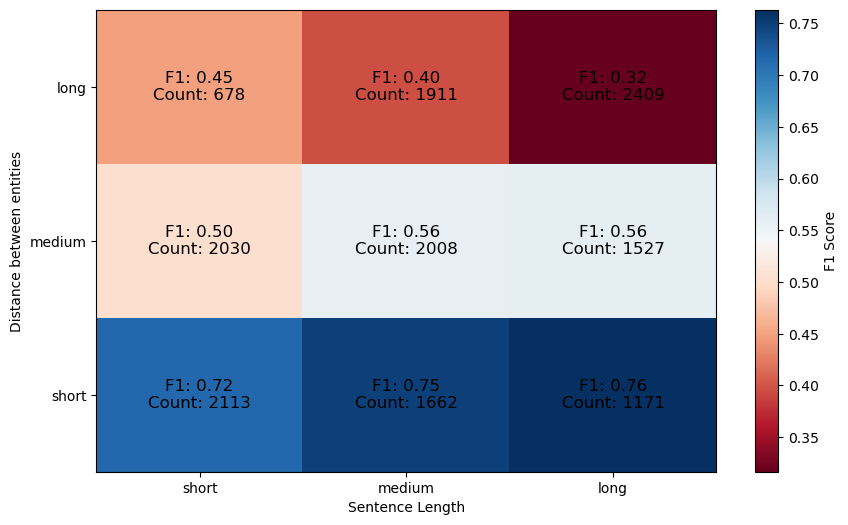

In [14]:
results_data = {
    "distance": distances,
    "length": lengths,
    "f1_score": f1s,
    "precision": precisions,
    "recall": recalls,
    "counts": counts,
}

results_df = pd.DataFrame(results_data)

# Reshape the DataFrame for heatmap
heatmap_data_f1 = results_df.pivot(
    index="distance", columns="length", values="f1_score"
)
heatmap_data_f1 = heatmap_data_f1.iloc[:, ::-1]
heatmap_data_f1 = heatmap_data_f1[::-1]

# Plot the heatmap for F1 Score with count annotations using a diverging color scale
plt.figure(figsize=(10, 6))
heatmap = plt.imshow(
    heatmap_data_f1,
    cmap="RdBu",
    interpolation="nearest",
    aspect="auto",
    vmin=heatmap_data_f1.values.min(),
    vmax=heatmap_data_f1.values.max(),
    origin="lower",
)

# Annotate each tile with the count
for i in range(len(heatmap_data_f1.index)):
    for j in range(len(heatmap_data_f1.columns)):
        count_value = results_df[
            (results_df["distance"] == heatmap_data_f1.index[i])
            & (results_df["length"] == heatmap_data_f1.columns[j])
        ]["counts"].values[0]
        plt.text(
            j,
            i,
            f"F1: {heatmap_data_f1.iloc[i, j]:.2f}\nCount: {count_value}",
            ha="center",
            va="center",
            color="black",
            fontsize=12,
        )

plt.colorbar(heatmap, label="F1 Score")
plt.xticks(np.arange(len(heatmap_data_f1.columns)), heatmap_data_f1.columns)
plt.yticks(np.arange(len(heatmap_data_f1.index)), heatmap_data_f1.index)
plt.xlabel("Sentence Length")
plt.ylabel("Distance between entities")
plt.title("")
plt.show()

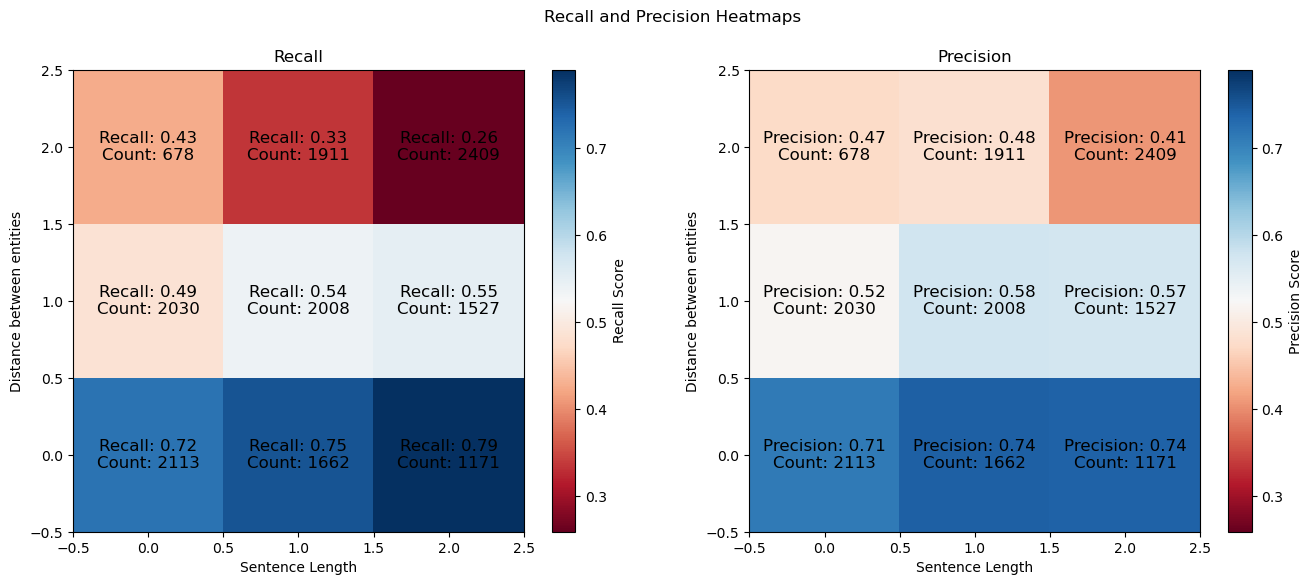

In [15]:
heatmap_data_recall = results_df.pivot(
    index="distance", columns="length", values="recall"
)
heatmap_data_recall = heatmap_data_recall.iloc[:, ::-1]
heatmap_data_recall = heatmap_data_recall[::-1]

heatmap_data_precision = results_df.pivot(
    index="distance", columns="length", values="precision"
)
heatmap_data_precision = heatmap_data_precision.iloc[:, ::-1]
heatmap_data_precision = heatmap_data_precision[::-1]

# Calculate common vmin and vmax
vmin = min(heatmap_data_recall.values.min(), heatmap_data_precision.values.min())
vmax = max(heatmap_data_recall.values.max(), heatmap_data_precision.values.max())

# Plot side-by-side subplots for recall and precision
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot for Recall
heatmap_recall = axes[0].imshow(
    heatmap_data_recall,
    cmap="RdBu",
    interpolation="nearest",
    aspect="auto",
    vmin=vmin,
    vmax=vmax,
    origin="lower",
)

# Annotate each tile with the count
for i in range(len(heatmap_data_recall.index)):
    for j in range(len(heatmap_data_recall.columns)):
        count_value = results_df[
            (results_df["distance"] == heatmap_data_recall.index[i])
            & (results_df["length"] == heatmap_data_recall.columns[j])
        ]["counts"].values[0]
        axes[0].text(
            j,
            i,
            f"Recall: {heatmap_data_recall.iloc[i, j]:.2f}\nCount: {count_value}",
            ha="center",
            va="center",
            color="black",
            fontsize=12,
        )

axes[0].set_title("Recall")
axes[0].set_xlabel("Sentence Length")
axes[0].set_ylabel("Distance between entities")
fig.colorbar(heatmap_recall, ax=axes[0], label="Recall Score")

# Plot for Precision
heatmap_precision = axes[1].imshow(
    heatmap_data_precision,
    cmap="RdBu",
    interpolation="nearest",
    aspect="auto",
    vmin=vmin,
    vmax=vmax,
    origin="lower",
)

# Annotate each tile with the count
for i in range(len(heatmap_data_precision.index)):
    for j in range(len(heatmap_data_precision.columns)):
        count_value = results_df[
            (results_df["distance"] == heatmap_data_precision.index[i])
            & (results_df["length"] == heatmap_data_precision.columns[j])
        ]["counts"].values[0]
        axes[1].text(
            j,
            i,
            f"Precision: {heatmap_data_precision.iloc[i, j]:.2f}\nCount: {count_value}",
            ha="center",
            va="center",
            color="black",
            fontsize=12,
        )

axes[1].set_title("Precision")
axes[1].set_xlabel("Sentence Length")
axes[1].set_ylabel("Distance between entities")
fig.colorbar(heatmap_precision, ax=axes[1], label="Precision Score")

plt.suptitle("Recall and Precision Heatmaps")
plt.show()

We can see that while also precision is affected, it appears that recall degrades the most when considering sentences with longer distance between the entities.

Now we obtain the same plot on a more precise scale, by computing the F1 score for each possible pair of (sentence_length, entity_distance) present in the dataset.

In [17]:
blockPrint()
unique_sentence_length = test_data["sentence_length"].unique()
unique_entity_distance = test_data["entity_distance"].unique()
sls = []
eds = []
f1s = []
counts = []
for sl in unique_sentence_length:
    for ed in unique_entity_distance:
        sls.append(sl)
        eds.append(ed)
        predicted = test_data["predicted"][
            (test_data["sentence_length"] == sl) & (test_data["entity_distance"] == ed)
        ]
        counts.append(len(predicted))
        exact = test_data["relation"][
            (test_data["sentence_length"] == sl) & (test_data["entity_distance"] == ed)
        ]
        if len(predicted) == 0:
            f1s.append(None)
        else:
            out = scorer.score(list(exact), list(predicted))
            f1s.append(out[2])
enablePrint()

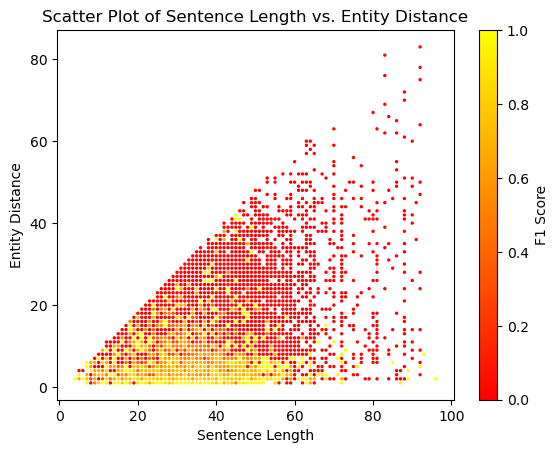

In [18]:
plt.scatter(
    sls, eds, c=f1s, cmap="autumn", marker="o", s=2
)  # Adjust the 's' parameter for dot size

# Set labels and title
plt.xlabel("Sentence Length")
plt.ylabel("Entity Distance")
plt.title("Scatter Plot of Sentence Length vs. Entity Distance")

# Add a colorbar
cbar = plt.colorbar()
cbar.set_label("F1 Score")

# Show the plot
plt.show()

We can see the same behaviour as above. It is also clear that the main issue seems to be the entity distance. In fact even on long sentences with small entity distance the perfroamnce is quite good, while when the entity distance is almost as big as the sentence length, we mainly observe F1 values of 0 (see close to the diagonal).